In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
ticker = input("Enter the stock Ticker (e.g.,RELIANCE.NS, AAPL): ")
period = input("Enter the period (e.g., 1y, 5y, 6mo, max): ")

data = yf.download(ticker, period=period, multi_level_index= False)

if not data.empty:
    print(f"\n---Analsis for {ticker}----")
    print(data.tail())
else:
    print("No data found. Please check the ticker symbol.")


Enter the stock Ticker (e.g.,RELIANCE.NS, AAPL):  RELIANCE.NS
Enter the period (e.g., 1y, 5y, 6mo, max):  5Y


[*********************100%***********************]  1 of 1 completed


---Analsis for RELIANCE.NS----
                  Close         High          Low         Open    Volume
Date                                                                    
2026-04-07  1304.599976  1308.300049  1291.000000  1295.000000  28388922
2026-04-08  1347.800049  1350.599976  1326.199951  1349.000000  21817543
2026-04-09  1330.000000  1350.000000  1326.300049  1346.000000  20725390
2026-04-10  1350.199951  1352.300049  1331.500000  1337.000000  19364461
2026-04-13  1315.099976  1327.599976  1310.000000  1321.199951  28745744


In [23]:
Close = data["Close"].squeeze() #Extract closing price
data["Daily_return"] = Close.pct_change().fillna(0) #Daily returnn
data["Cumulative_return"] = (1 + data["Daily_return"]).cumprod() #Cumulative return
# Moving Averages
data["MA_50"] = Close.rolling(window=50).mean()
data["MA_200"] = Close.rolling(window=200).mean()

#Volatility (annualized)
daily_vol = data["Daily_return"].std()
annual_vol = daily_vol * np.sqrt(252)

# Sharpe ratio
avg_daily_return = data["Daily_return"].mean()
sharpe_ratio = (avg_daily_return / daily_vol) * np.sqrt(252)

print(f"Financial summary for {ticker}\n")
print(f"Start Price: ${float(Close.iloc[0]):.2f}")
print(f"End Price: ${float(Close.iloc[-1]):.2f}")
print(f"Cumulative_return: {float(data['Cumulative_return'].iloc[-1]) * 100:.2f}%")
print(f"Annualized vol: {float(annual_vol) * 100:.2f}%")
print(f"Sharpe ratio: {float(sharpe_ratio):.2f}")


Financial summary for RELIANCE.NS

Start Price: $875.94
End Price: $1315.10
Cumulative_return: 150.14%
Annualized vol: 22.39%
Sharpe ratio: 0.48


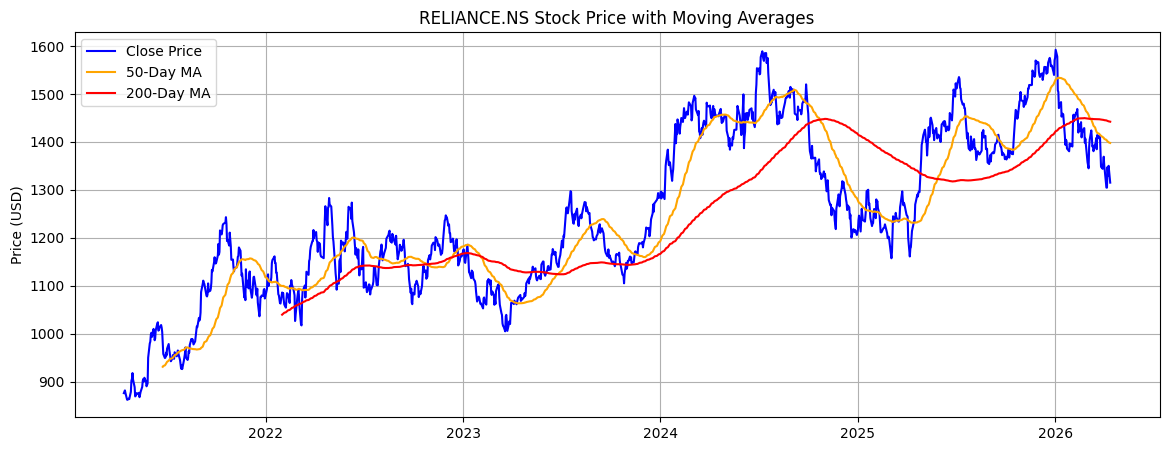

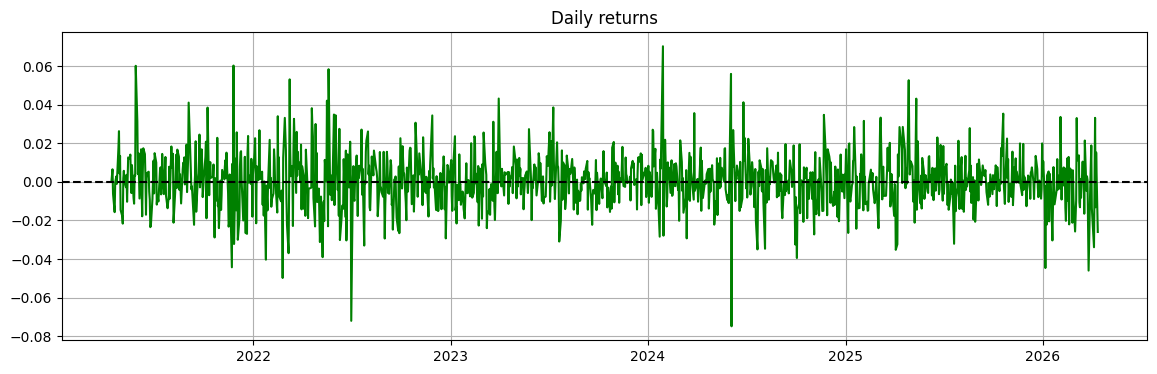

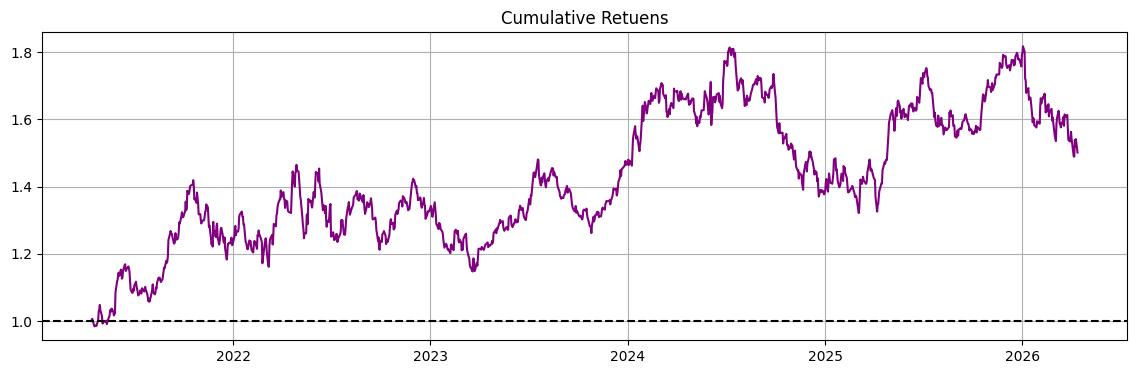

In [24]:
# Chart 1 - Price with Moving Averages
plt.figure(figsize=(14,5))
plt.plot(data["Close"], label="Close Price", color="blue")
plt.plot(data["MA_50"], label="50-Day MA", color="orange")
plt.plot(data["MA_200"], label="200-Day MA", color="red")
plt.title(f"{ticker} Stock Price with Moving Averages")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Chart 2 - Daily returns
plt.figure(figsize=(14, 4))
plt.plot(data["Daily_return"], color="green")
plt.axhline(y=0, color="black", linestyle="--")
plt.title("Daily returns")
plt.grid(True)
plt.show()

# Chart 3 - Cumulative returns
plt.figure(figsize=(14,4))
plt.plot(data["Cumulative_return"], color="purple")
plt.axhline(y=1, color="black", linestyle="--")
plt.title("Cumulative Retuens")
plt.grid(True)
plt.show()


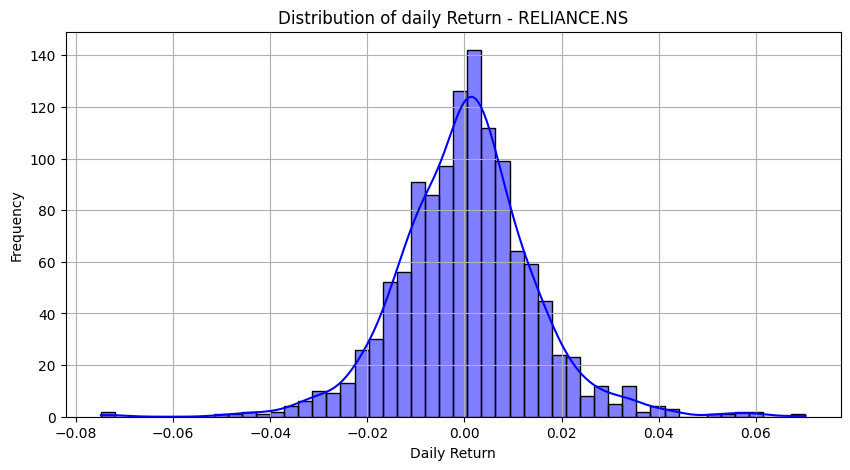

In [ ]:
# Chart 1 - Distribution of Daily Returns
plt.figure(figsize=(10,5))
sns.histplot(data["Daily_return"].dropna(), bins=50, kde=True, color="blue")
plt.title(f"Distribution of daily Return - {ticker}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Chart 2 - Correlation Heatmap (Multiple Stocks)
Peers = input("Enter peer tickers separated by commas (e.g., IOC.NS, AAPL- (for india use .NS or .BO)): ")
Peers_list = [p.strip().upper() for p in Peers.split(",") if p.strip()]
tickers = [ticker] + Peers_list

print(f"Fetching data for:  {tickers}...")
multi_data = yf.download(tickers, period=period, multi_level_index= False)["Close"]

returns_all = multi_data.pct_change().dropna()
correlation = returns_all.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title(f"stock correlation heatmap - {ticker} vs Peers")
plt.show()


In [26]:
# final summary cell
print("=" * 45)
print("     STOCK DASHBOARD - FINAL REPORT   ")
print("=" * 45)
print(f"\nStock: {ticker}")
print(f"\nPeriod: {period}")
print(f"\nStart Price: {float(Close.iloc[0]):.2f}")
print(f"\nEnd Price: {float(Close.iloc[-1]):.2f}")
print(f"\nTotal Return: {(float(data['Cumulative_return'].iloc[-1])-1)* 100:.2f}%")
print(f"\nVolatity: {float(annual_vol)* 100:.2f}%")
print(f"\nsharp ratio: {float(sharpe_ratio):2f}")
print(f"\n"+"="*45)

# Sharpe ratio verdict
if sharpe_ratio>2:
    print("verdict: excellent risk-adjusted return!")
elif sharpe_ratio>1:
    print("verdict: good risk-adjusted return!")
else:
    print("verdict: Poor risk-adjusted return!")

print("="*45)


     STOCK DASHBOARD - FINAL REPORT   

Stock: RELIANCE.NS

Period: 5Y

Start Price: 875.94

End Price: 1315.10

Total Return: 50.14%

Volatity: 22.39%

sharp ratio: 0.481825

verdict: Poor risk-adjusted return!
